Simplest trading strategy, verifing crosses of 2 moving avg and buying following the rule that if the small crosses the big one so the market tendency is bullish.

In [71]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ['NVDA', 'GOOGL', 'AAPL', 'GOOG', 'MSFT', 'AMZN', 'TSM', 'AVGO', 'META', 'TSLA', 'SMCI']

[*********************100%***********************]  1 of 1 completed


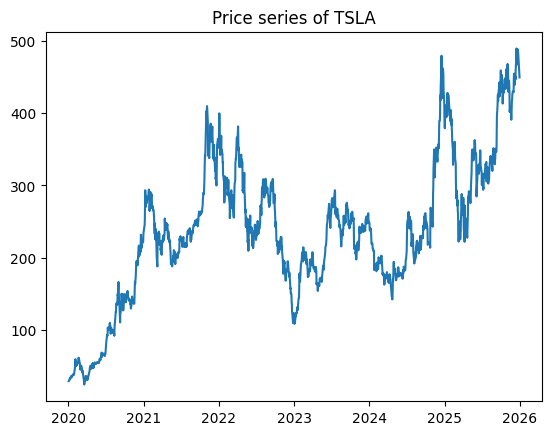

In [81]:
# here i will import the data for creating the time series
stock = 'TSLA'
data = yf.download(stock, start='2020-01-01', end='2026-01-01', interval='1d')

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data.dropna().copy()
data.index = pd.to_datetime(data.index)
data = data.sort_index()

data.head()
plt.plot(data['Close'])
plt.title(f'Price series of {stock}')
plt.show()

In [73]:
# moving avg
small1 = 20
big1 = 50
small2 = 50
big2 = 200

data[f'MA_{small1}'] = data['Close'].rolling(small1).mean()
data[f'MA_{big1}'] = data['Close'].rolling(big1).mean()

data[f'MA_{small2}'] = data['Close'].rolling(small2).mean()
data[f'MA_{big2}'] = data['Close'].rolling(big2).mean()

In [74]:
# strategy
data['signal1'] = 0
data['signal2'] = 0
data.loc[data[f'MA_{small1}'] > data[f'MA_{big1}'],'signal1'] = 1
data.loc[data[f'MA_{small2}'] > data[f'MA_{big2}'],'signal2'] = 1
data.loc[data[f'MA_{small1}'] < data[f'MA_{big1}'],'signal1'] = -1
data.loc[data[f'MA_{small2}'] < data[f'MA_{big2}'],'signal2'] = -1

data['trade1'] = data['signal1'].diff()
data['trade2'] = data['signal2'].diff()

# actual action
data.loc[data['trade1'] > 0, 'trade1'] = 1
data.loc[data['trade1'] < 0, 'trade1'] = -1
data.loc[data['trade2'] > 0, 'trade2'] = 1
data.loc[data['trade2'] < 0, 'trade2'] = -1

# daily return
data['daily_return'] = data['Close'].pct_change()

data['position1'] = data['signal1'].shift()
data['position2'] = data['signal2'].shift()

data['strategy_return1'] = data['position1']*data['daily_return']
data['strategy_return2'] = data['position2']*data['daily_return']

# calculate strategy return
data['equity1'] = (1+data['strategy_return1'].fillna(0)).cumprod()
data['equity2'] = (1+data['strategy_return2'].fillna(0)).cumprod()

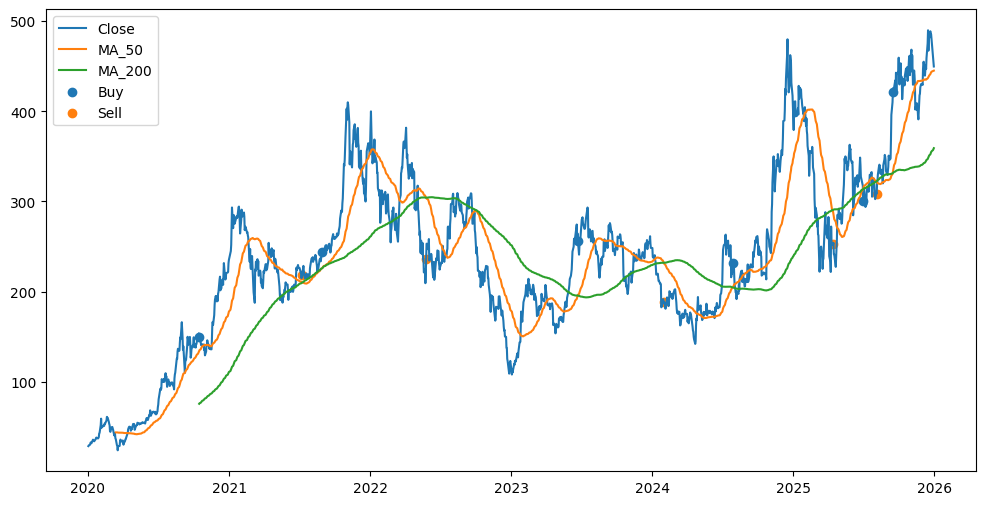

Final return:
A_50 vs 200: 0.25422437913565005
MA_20 vs 50: 0.3721034625238852
stock return: 14.678427031845953


In [75]:
# plot trading point and printing returns

plt.figure(figsize=(12, 6))

plt.plot(data['Close'], label='Close')
plt.plot(data[f'MA_{small2}'], label=f'MA_{small2}')
plt.plot(data[f'MA_{big2}'], label=f'MA_{big2}')

buy_points = data['trade2'] == 1
sell_points = data['trade2'] == -1

plt.scatter(data.index[buy_points], data.loc[buy_points, 'Close'], label='Buy')
plt.scatter(data.index[sell_points], data.loc[sell_points, 'Close'], label='Sell')

plt.legend()
plt.show()

print(f'Final return:')
print(f"A_50 vs 200: {data['equity2'].iloc[-1]}")
print(f"MA_20 vs 50: {data['equity1'].iloc[-1]}")
print(f"stock return: {(data['Close'].iloc[-1]-data['Close'].iloc[0])/data['Close'].iloc[0]}")

Definition of ad-hoc metrics that measure not just the model performance but financial outcome of the tested strategy.

In [76]:
# calculate sharpe

rf = 0.02 / 252 # 252 number of trading days

sharpe1 = (data['strategy_return1']-rf).mean() / data['strategy_return1'].std() * np.sqrt(252) 
sharpe2 = (data['strategy_return2']-rf).mean() / data['strategy_return2'].std() * np.sqrt(252)
sharpe_buy_hold = (data['daily_return']-rf).mean() / (data['daily_return']).std() * np.sqrt(252)

print(f'Sharpe ratio (MA50 vs 20): {sharpe1}')
print(f'Sharpe ratio (MA200 vs 50): {sharpe2}')
print(f'Sharpe ratio (buy and hold): {sharpe_buy_hold}')

Sharpe ratio (MA50 vs 20): 0.0333908470043323
Sharpe ratio (MA200 vs 50): -0.15871287275144044
Sharpe ratio (buy and hold): 0.9931056339616771


In [77]:
# max drawdown

actual1 = data['equity1']
rolling_max = actual1.cummax()
drawdown = (actual1 - rolling_max) / rolling_max

max_dd = drawdown.min()
end_dd_date = (drawdown.idxmin())
start_dd_date = (data.loc[data.index < end_dd_date, 'Close']).idxmax()

print(f'Maximum drawdown over the backtested period is: {max_dd}')
print(f'Started in: {start_dd_date}, ended in: {end_dd_date}')


Maximum drawdown over the backtested period is: -0.8408816575138164
Started in: 2021-11-04 00:00:00, ended in: 2024-04-29 00:00:00


In [78]:
# winning trades
# to identify a winning trades I have to compare the entry price and exit price (if long it needs to be smaller and viceversa)

data['entry1'] = data.loc[data['trade1'] != 0, 'Close']
data['entry2'] = data.loc[data['trade2'] != 0, 'Close']

wins = []
losts = []
for i in ["1","2"]:

    win = 0
    lost = 0
    flag = False
    for el in range(len(data)):
        if data[f'trade{i}'].iloc[el] != 0 and flag == False:
            flag = True
            init_price = data[f'entry{i}'].iloc[el]
            direction = data[f'trade{i}'].iloc[el]

        elif flag and data[f'trade{i}'].iloc[el] != 0:
            if direction == 1:
                if data[f'entry{i}'].iloc[el] > init_price:
                    win += 1
                else:
                    lost += 1
                
            else:
                if data[f'entry{i}'].iloc[el] < init_price:
                    win += 1 
                else:
                    lost += 1 

            flag = False
    
    wins.append(win)
    losts.append(lost)

print(f"The number of trade is:")
print(f"MA20 vs 50 -- Won: {wins[0]} and lost: {losts[0]}")
print(f"MA50 vs 200 -- Won: {wins[1]} and lost: {losts[1]}")

The number of trade is:
MA20 vs 50 -- Won: 4 and lost: 13
MA50 vs 200 -- Won: 0 and lost: 6


In [79]:
# sortino ratio

downside_returns1 = data.loc[data['strategy_return1'] < 0, 'strategy_return1']
downside_returns2 = data.loc[data['strategy_return2'] < 0, 'strategy_return2']
downside_returns_buy_hold = data.loc[data['daily_return'] < 0, 'daily_return']


sortino1 = (data['strategy_return1']-rf).mean() / downside_returns1.std() * np.sqrt(252) # it always need to be annualazied because the return over which we calculate std are over more years
sortino2 = (data['strategy_return2']-rf).mean() / downside_returns2.std() * np.sqrt(252)
sortino_buy_hold = (data['daily_return']-rf).mean() / downside_returns_buy_hold.std() * np.sqrt(252)

print(f'Sortino ratio (MA50 vs 20): {sortino1}')
print(f'Sortino ratio (MA200 vs 50): {sortino2}')
print(f'Sortino ratio (buy and hold): {sortino_buy_hold}')

Sortino ratio (MA50 vs 20): 0.046169295039876844
Sortino ratio (MA200 vs 50): -0.23095532263392388
Sortino ratio (buy and hold): 1.5132404835056528
